In [6]:
import numpy as np 
import os 
import xarray as xr
import pandas as pd
#from scipy.io import savemat
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib as mpl
from matplotlib import colors
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import cm
import matplotlib

import mplcursors

## Without Interpolation

In [8]:
#load file for all dates
all_days_filepath = '../../CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

In [9]:
# Step 1: Calculate the 8-hour rolling average
df_8hr_avg_ozone = df_alldays['O3_ppbv'].rolling(window=16, min_periods=16).mean()
#rolling average only works for 8 hours with no gaps; at least 6 hours
#print(df_adjuststart_hourly_ozone)

# Step 2: Calculate the maximum 8-hour average for each day
# Resample to daily frequency, compute the daily max of the rolling averages, drop NA values
daily_max_8hr_avg_ozone = df_8hr_avg_ozone.resample('D').max().dropna()
#print('Max 8 hr avg each day:\n, adjuststart_daily_max_8hr_avg_ozone)

# Step 3: Map the daily maximum back to the original dataframe
# Create a new temporary column with the daily max 8-hour average for each timestamp
df_alldays['MDA8_O3'] = df_alldays.index.floor('D').map(daily_max_8hr_avg_ozone)
#print('Daily max 8 hour avg for each timestamp: \n', df_adjuststart_hourly_ozone['MDA8_O3'])

# Select daytime values only where MD8A > 70
df_ozone_day_exceedance = df_alldays[(df_alldays.index.hour >=7) & (df_alldays.index.hour<=20) & (df_alldays['MDA8_O3']>70)]
print('When is MDA8 > 70?', df_ozone_day_exceedance)

When is MDA8 > 70?                                time_UTC    O3_ppbv  File_Index  HONO_CIMS  \
time_local                                                                  
2024-07-16 07:00:00 2024-07-16 13:00:00        NaN         1.0   0.128431   
2024-07-16 07:30:00 2024-07-16 13:30:00        NaN         1.0   0.067931   
2024-07-16 08:00:00 2024-07-16 14:00:00        NaN         1.0   0.070322   
2024-07-16 08:30:00 2024-07-16 14:30:00        NaN         1.0   0.072925   
2024-07-16 09:00:00 2024-07-16 15:00:00        NaN         1.0   0.070924   
...                                 ...        ...         ...        ...   
2024-08-08 18:30:00 2024-08-09 00:30:00  70.310556         1.0        NaN   
2024-08-08 19:00:00 2024-08-09 01:00:00  69.506556         1.0        NaN   
2024-08-08 19:30:00 2024-08-09 01:30:00  65.344111         1.0        NaN   
2024-08-08 20:00:00 2024-08-09 02:00:00  63.494111         1.0   0.067457   
2024-08-08 20:30:00 2024-08-09 02:30:00  55.970667       

Text(0.5, 1.0, 'MDA8 Ozone for USOS Without Interpolation')

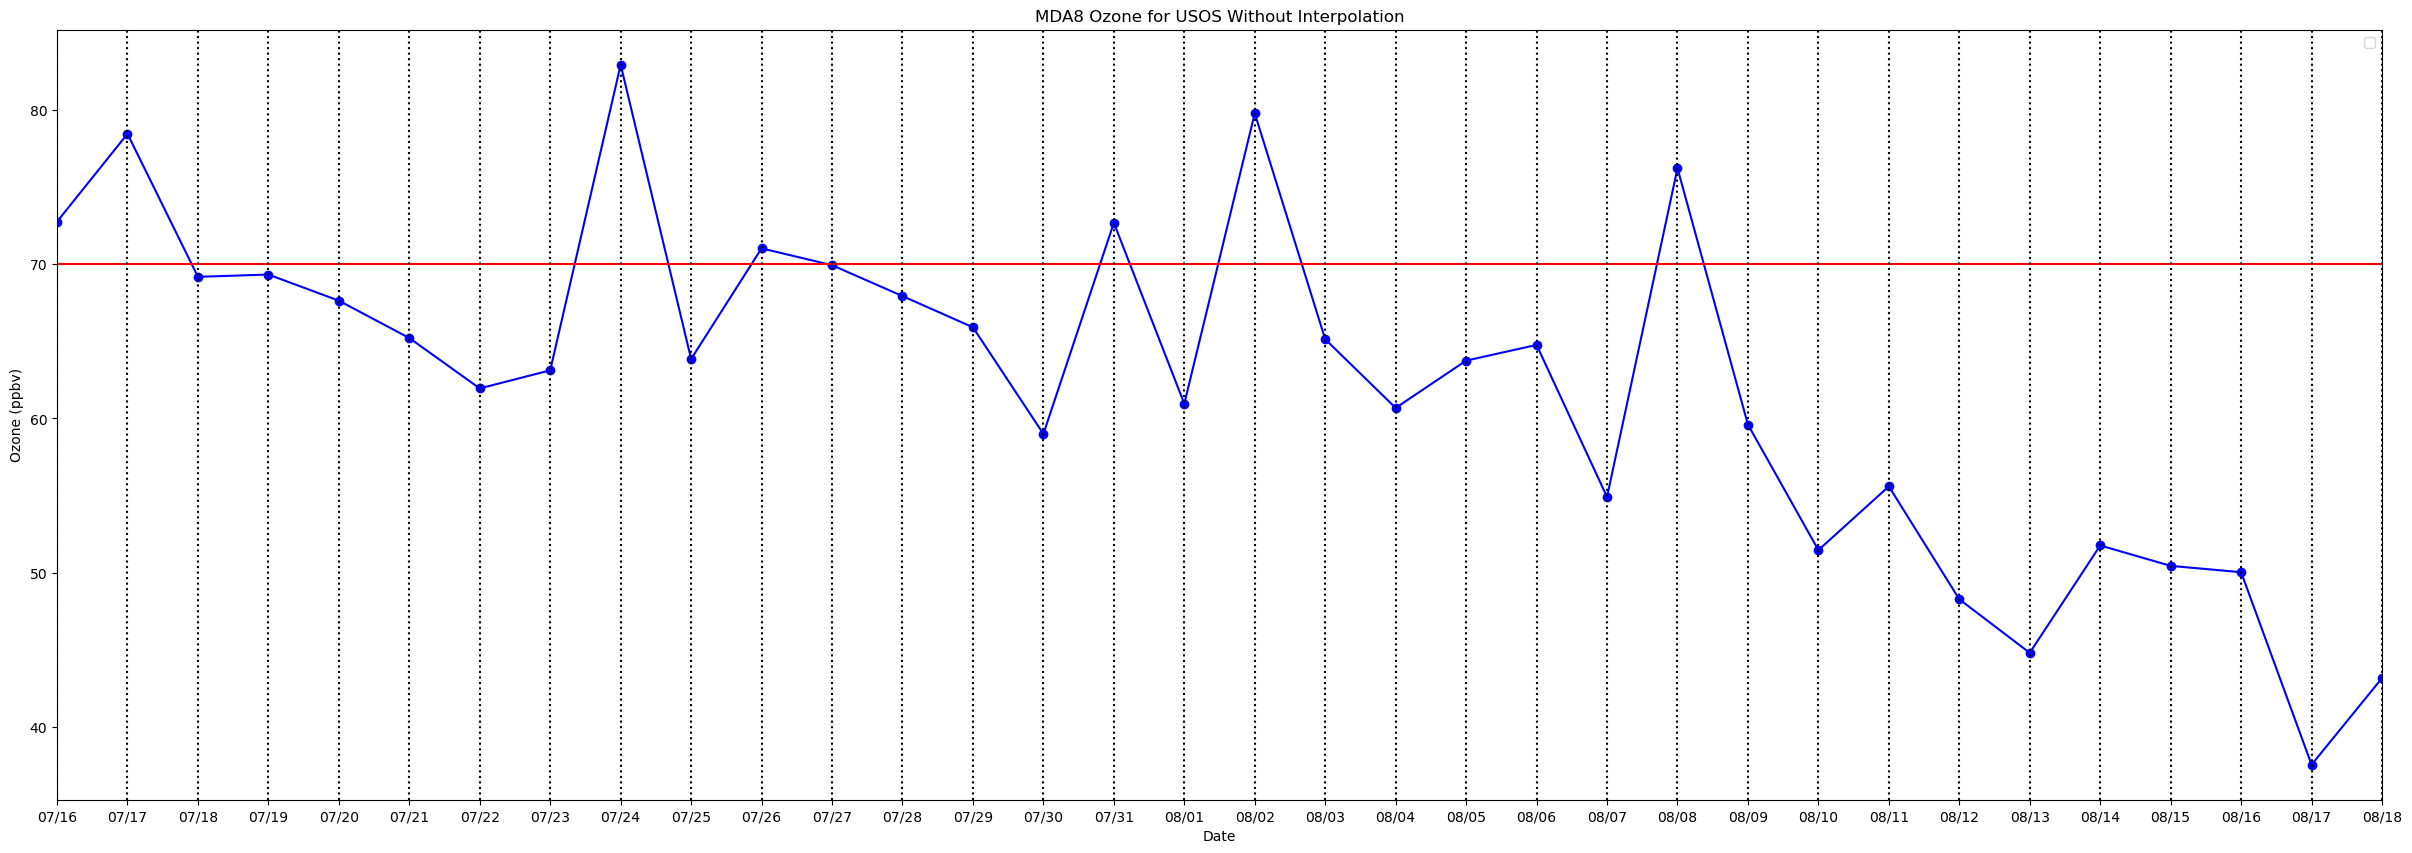

In [10]:
fig, ax1 = plt.subplots(figsize = (30,10))

ax1.margins(x=0)

ax1.plot(daily_max_8hr_avg_ozone.index, daily_max_8hr_avg_ozone, color='b',marker='o')

ax1.set_ylabel('Ozone (ppbv)')
ax1.set_xlabel('Date')

ax1.hlines(y=70, xmin = daily_max_8hr_avg_ozone.index[0], xmax = daily_max_8hr_avg_ozone.index[len(daily_max_8hr_avg_ozone)-1], color = 'r')

ax1.set_xticks(daily_max_8hr_avg_ozone.index)
ax1.set_xticklabels(daily_max_8hr_avg_ozone.index.strftime('%m/%d'))

# midnight_vals_30min = []
# for midnight_idx_30min in range(16,len(df_adjuststart_30min_ozone.index),48):
#     midnight_vals_30min.append(df_adjuststart_30min_ozone.index[midnight_idx_30min])
for day_pos_30min in daily_max_8hr_avg_ozone.index:
    ax1.axvline(day_pos_30min, color = 'black', linestyle = 'dotted')


lines, labels = ax1.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines, labels, loc=0)
plt.title('MDA8 Ozone for USOS Without Interpolation')

# With Interpolation

In [11]:
#Where are the NaNs? This will help us choose which days to cut off in the beginning
for o3_val in range(0,len(df_alldays['O3_ppbv'])):
    nan_check = np.isnan(df_alldays['O3_ppbv'].values[o3_val])
    if nan_check == True:
        print(df_alldays.index[o3_val])

2024-07-14 18:00:00
2024-07-14 18:30:00
2024-07-14 19:00:00
2024-07-14 19:30:00
2024-07-14 20:00:00
2024-07-14 20:30:00
2024-07-14 21:00:00
2024-07-14 21:30:00
2024-07-14 22:00:00
2024-07-14 22:30:00
2024-07-14 23:00:00
2024-07-14 23:30:00
2024-07-15 00:00:00
2024-07-15 00:30:00
2024-07-15 01:00:00
2024-07-15 01:30:00
2024-07-15 02:00:00
2024-07-15 02:30:00
2024-07-15 03:00:00
2024-07-15 03:30:00
2024-07-15 04:00:00
2024-07-15 04:30:00
2024-07-15 05:00:00
2024-07-15 05:30:00
2024-07-15 06:00:00
2024-07-15 06:30:00
2024-07-15 07:00:00
2024-07-15 07:30:00
2024-07-15 08:00:00
2024-07-15 08:30:00
2024-07-15 09:00:00
2024-07-15 09:30:00
2024-07-15 10:00:00
2024-07-15 10:30:00
2024-07-15 11:00:00
2024-07-15 11:30:00
2024-07-15 12:00:00
2024-07-15 12:30:00
2024-07-15 13:00:00
2024-07-15 13:30:00
2024-07-15 14:00:00
2024-07-15 14:30:00
2024-07-15 15:00:00
2024-07-15 15:30:00
2024-07-15 16:00:00
2024-07-15 16:30:00
2024-07-15 17:00:00
2024-07-15 17:30:00
2024-07-15 18:00:00
2024-07-15 18:30:00


In [12]:
df_july_ozone = df_alldays.sort_index().loc["2024-07-14 18:00:00":"2024-07-31 23:30:00"]
df_july_adjuststart_ozone = df_july_ozone['O3_ppbv'].to_frame()

df_august_ozone = df_alldays.sort_index().loc["2024-08-01":"2024-08-18 17:30:00"]
df_august_adjuststart_ozone = df_august_ozone['O3_ppbv'].to_frame()

In [13]:
#Count how many total Nans and negative points there are
n_baddies_july= len([item for item in df_july_adjuststart_ozone['O3_ppbv'] if item <0 or np.isnan(item)])
n_baddies_august= len([item for item in df_august_adjuststart_ozone['O3_ppbv'] if item <0 or np.isnan(item)])

#make a new column for interpolation, also setting any negatives to NaNs
df_alldays['O3_ppbv_interp'] = df_alldays['O3_ppbv'].mask(df_alldays['O3_ppbv'] < 0, np.nan)
df_july_adjuststart_ozone['O3_ppbv_interp'] = df_july_adjuststart_ozone['O3_ppbv'].mask(df_july_adjuststart_ozone['O3_ppbv'] < 0, np.nan)
df_august_adjuststart_ozone['O3_ppbv_interp'] = df_august_adjuststart_ozone['O3_ppbv'].mask(df_august_adjuststart_ozone['O3_ppbv'] < 0, np.nan)

In [14]:
#We interpolate all the NaNs
df_alldays['O3_ppbv_interp'] = df_alldays['O3_ppbv_interp'].interpolate(method='linear')
df_july_adjuststart_ozone['O3_ppbv_interp']  = df_july_adjuststart_ozone['O3_ppbv_interp'].interpolate(method='linear')
df_august_adjuststart_ozone['O3_ppbv_interp']  = df_august_adjuststart_ozone['O3_ppbv_interp'].interpolate(method='linear')

Text(0.5, 1.0, 'Interpolation for Ozone in July')

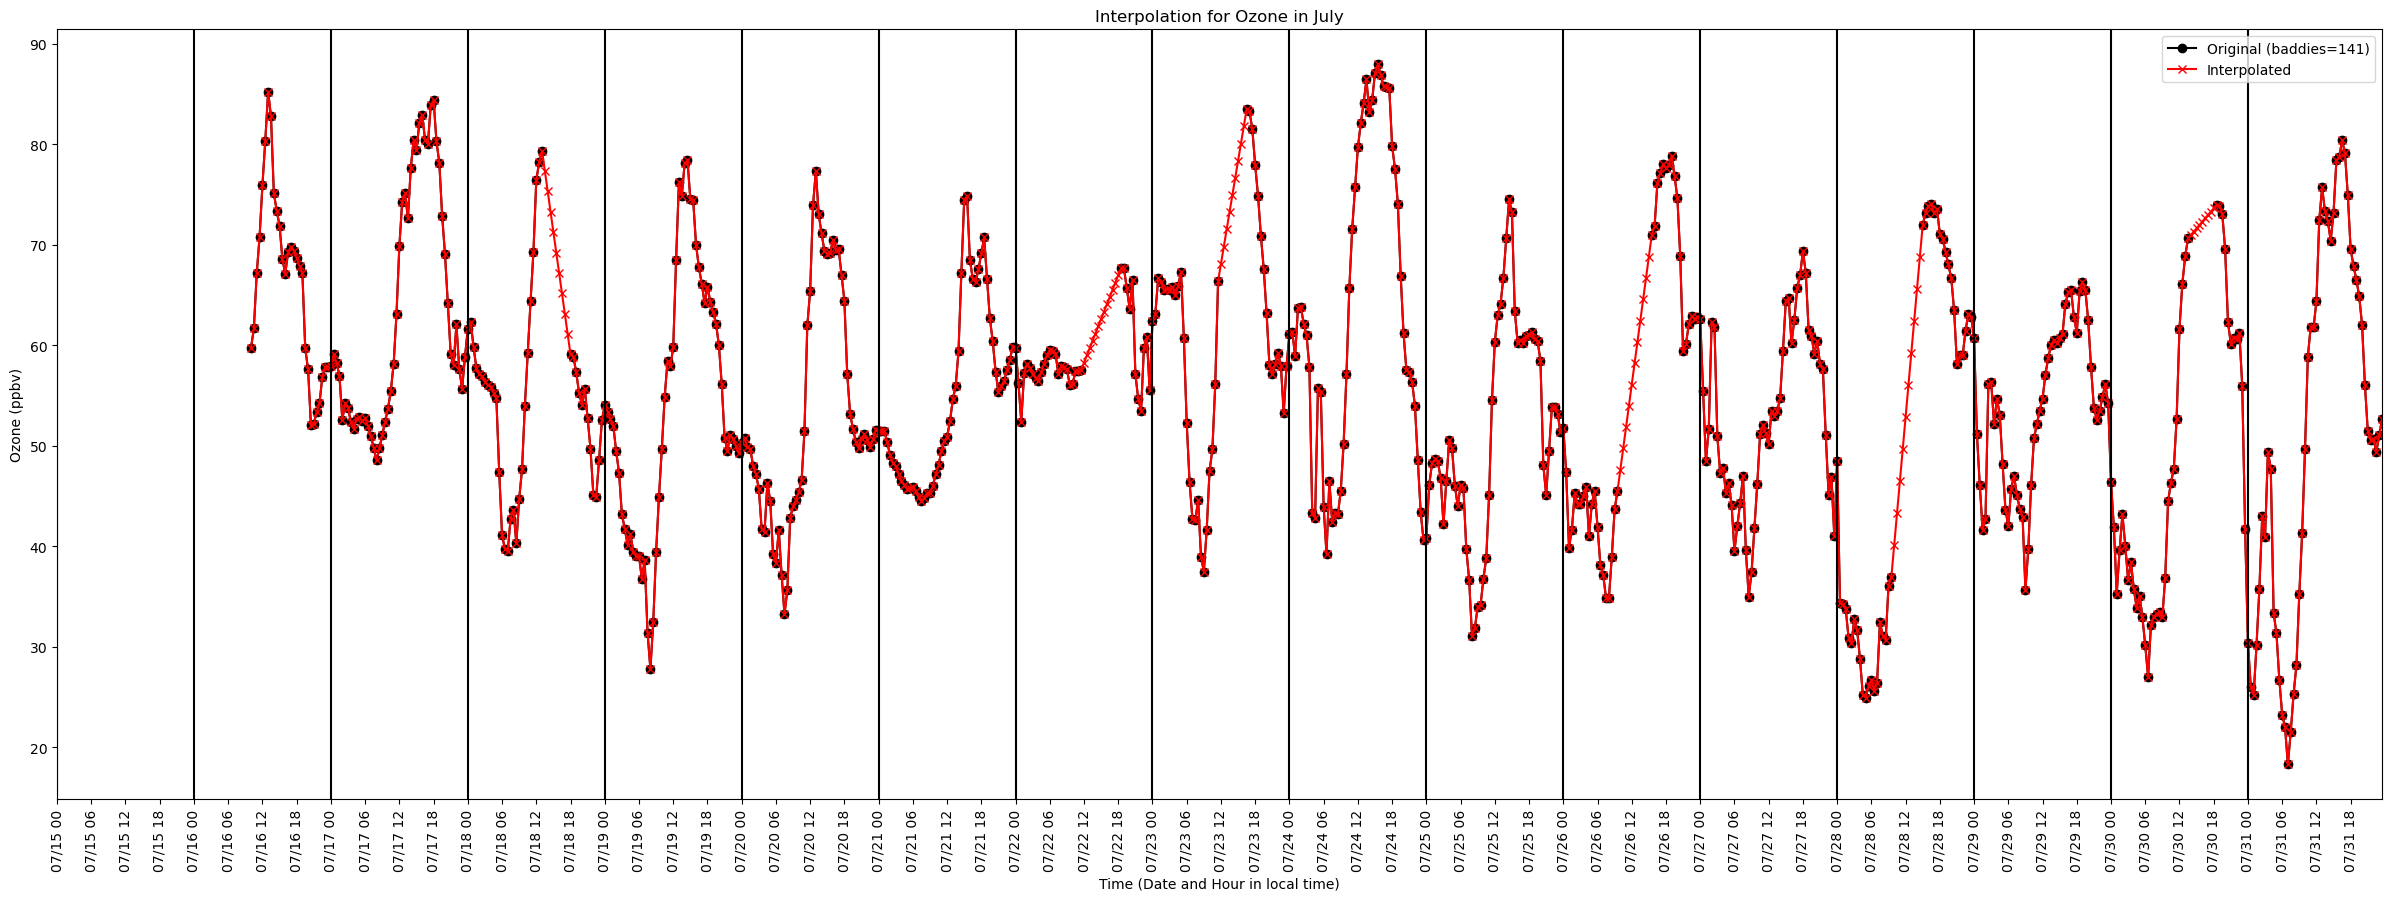

In [15]:
fig, ax = plt.subplots(figsize = (30,10))
plt.plot(df_july_adjuststart_ozone.index, df_july_adjuststart_ozone['O3_ppbv'], color='k', marker='o',label=f'Original (baddies={n_baddies_july})')
plt.plot(df_july_adjuststart_ozone.index, df_july_adjuststart_ozone['O3_ppbv_interp'], color='r', marker='x', label='Interpolated')

#Set x-axis intervals
ozone_ticks = []
for ozone_tick_idx in range(0,len(df_july_adjuststart_ozone.index),12):
    ozone_ticks.append(df_july_adjuststart_ozone.index[ozone_tick_idx])
    
plt.xticks(ticks=ozone_ticks, labels=df_july_adjuststart_ozone.index.strftime('%m/%d %H')[0::12], rotation = 90)

# #Draw vertical black line at midnight to distinguish the days
midnight_vals = []
for midnight_idx in range(12,len(df_july_adjuststart_ozone.index),48):
    midnight_vals.append(df_july_adjuststart_ozone.index[midnight_idx])
for day_pos in midnight_vals:
    plt.axvline(day_pos, color = 'black')

plt.margins(x=0)
plt.xlabel('Time (Date and Hour in local time)')
plt.ylabel('Ozone (ppbv)')

plt.legend()
plt.title('Interpolation for Ozone in July')

Text(0.5, 1.0, 'Interpolation for Ozone in August')

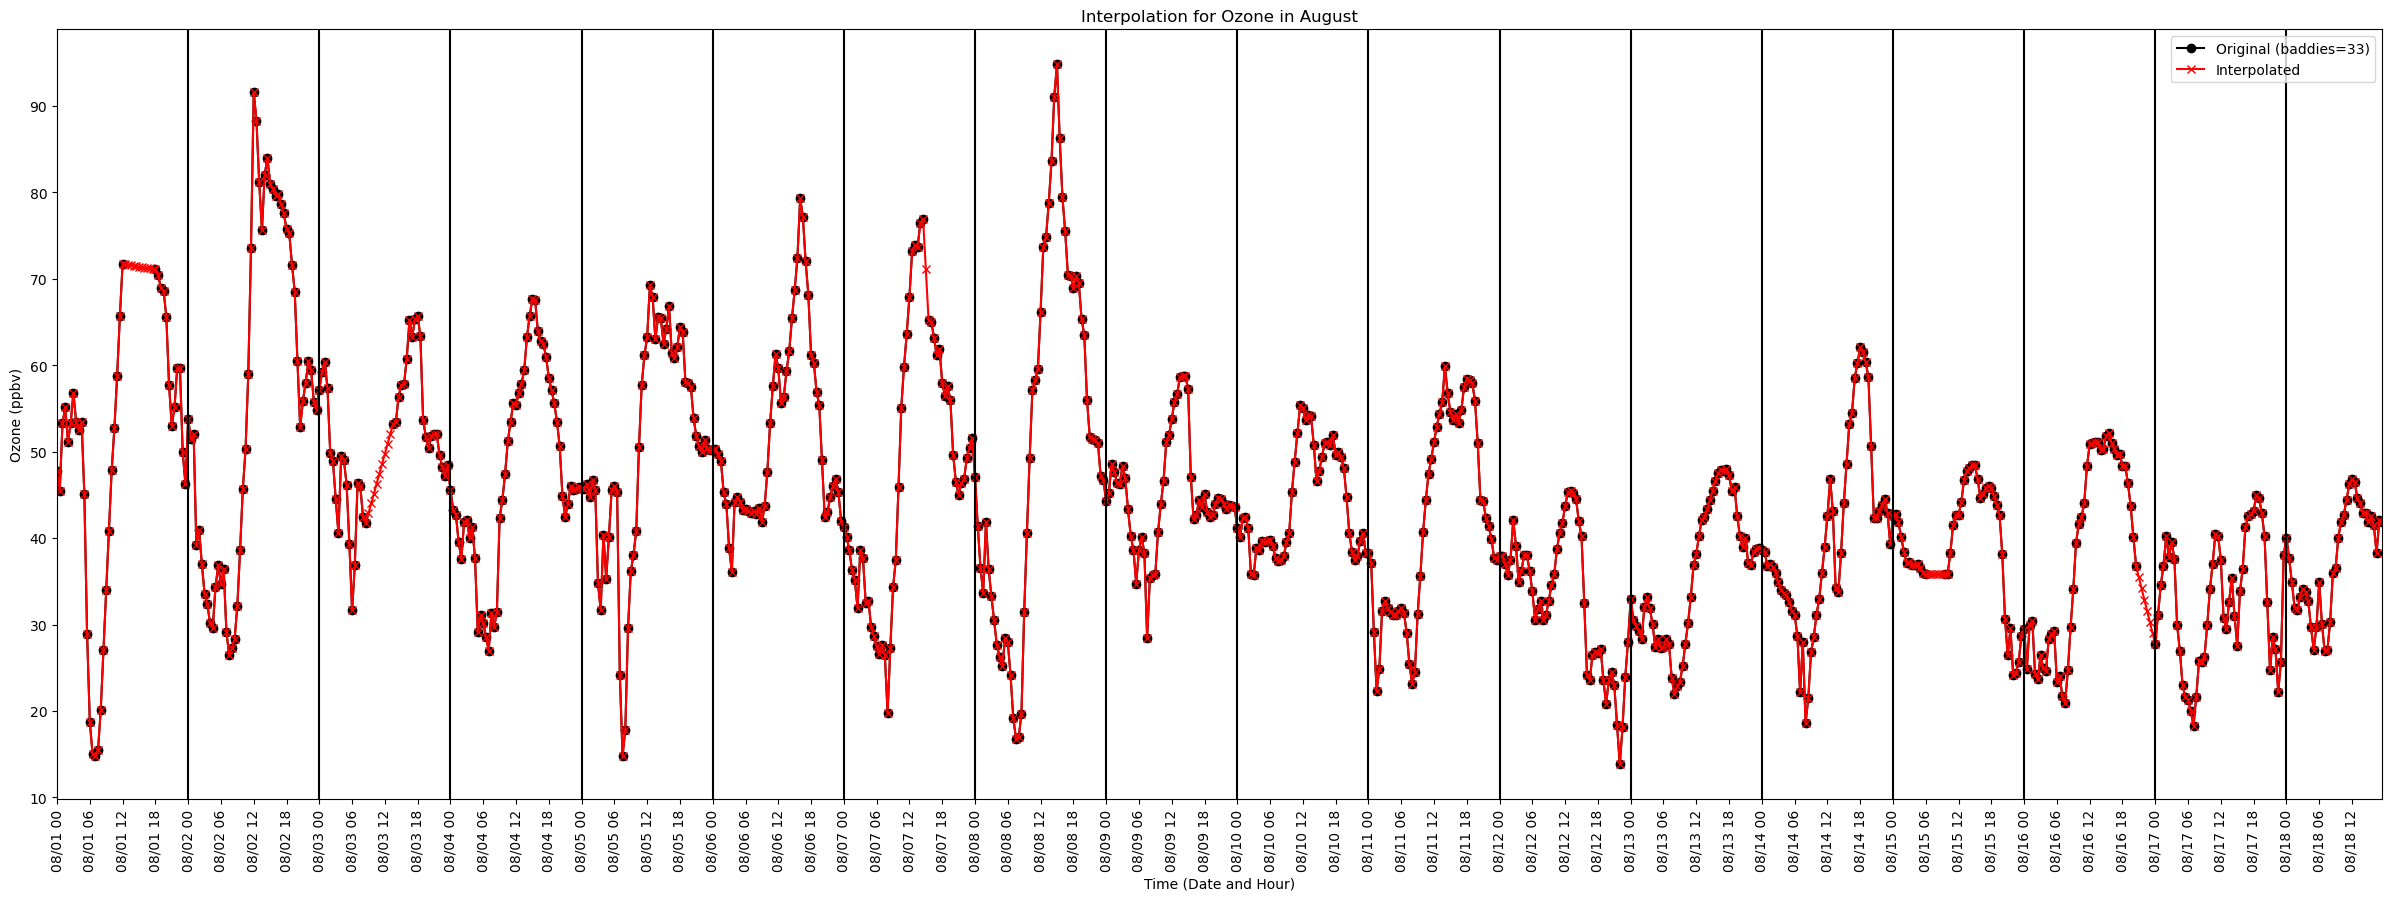

In [16]:
fig, ax = plt.subplots(figsize = (30,10))
plt.plot(df_august_adjuststart_ozone.index, df_august_adjuststart_ozone['O3_ppbv'], color='k', marker='o',label=f'Original (baddies={n_baddies_august})')
plt.plot(df_august_adjuststart_ozone.index, df_august_adjuststart_ozone['O3_ppbv_interp'], color='r', marker='x', label='Interpolated')

#Set x-axis intervals
ozone_ticks = []
for ozone_tick_idx in range(0,len(df_august_adjuststart_ozone.index),12):
    ozone_ticks.append(df_august_adjuststart_ozone.index[ozone_tick_idx])
    
plt.xticks(ticks=ozone_ticks, labels=df_august_adjuststart_ozone.index.strftime('%m/%d %H')[0::12], rotation = 90)

# #Draw vertical black line at midnight to distinguish the days
midnight_vals = []
for midnight_idx in range(48,len(df_august_adjuststart_ozone.index),48):
    midnight_vals.append(df_august_adjuststart_ozone.index[midnight_idx])
for day_pos in midnight_vals:
    plt.axvline(day_pos, color = 'black')

plt.margins(x=0)
plt.xlabel('Time (Date and Hour)')
plt.ylabel('Ozone (ppbv)')

plt.legend()
plt.title('Interpolation for Ozone in August')

In [17]:
# Step 1: Calculate the 8-hour rolling average
df_alldays['O3_8hr_avg'] = df_alldays['O3_ppbv_interp'].rolling(window=16, min_periods=16).mean()
#rolling average only works for 8 hours with no gaps; at least 6 hours
#print(df_adjuststart_hourly_ozone)

# Step 2: Calculate the maximum 8-hour average for each day
# Resample to daily frequency, compute the daily max of the rolling averages, drop NA values
adjuststart_daily_max_8hr_avg_ozone = df_alldays['O3_8hr_avg'].resample('D').max().dropna()
#print('Max 8 hr avg each day:\n', adjuststart_daily_max_8hr_avg_ozone)

# Step 3: Map the daily maximum back to the original dataframe
# Create a new temporary column with the daily max 8-hour average for each timestamp
df_alldays['MDA8_O3'] = df_alldays.index.floor('D').map(adjuststart_daily_max_8hr_avg_ozone)
#print('Daily max 8 hour avg for each timestamp: \n', df_adjuststart_hourly_ozone['MDA8_O3'])

# Select daytime values only where MD8A > 65
df_ozone_day_exceedance = df_alldays[(df_alldays.index.hour >=7) & (df_alldays.index.hour<=20) & (df_alldays['MDA8_O3']>70)]
#print('When is MDA8 > 70?\n', df_ozone_day_exceedance)

Text(0.5, 1.0, 'MDA8 Ozone for USOS With Interpolation')

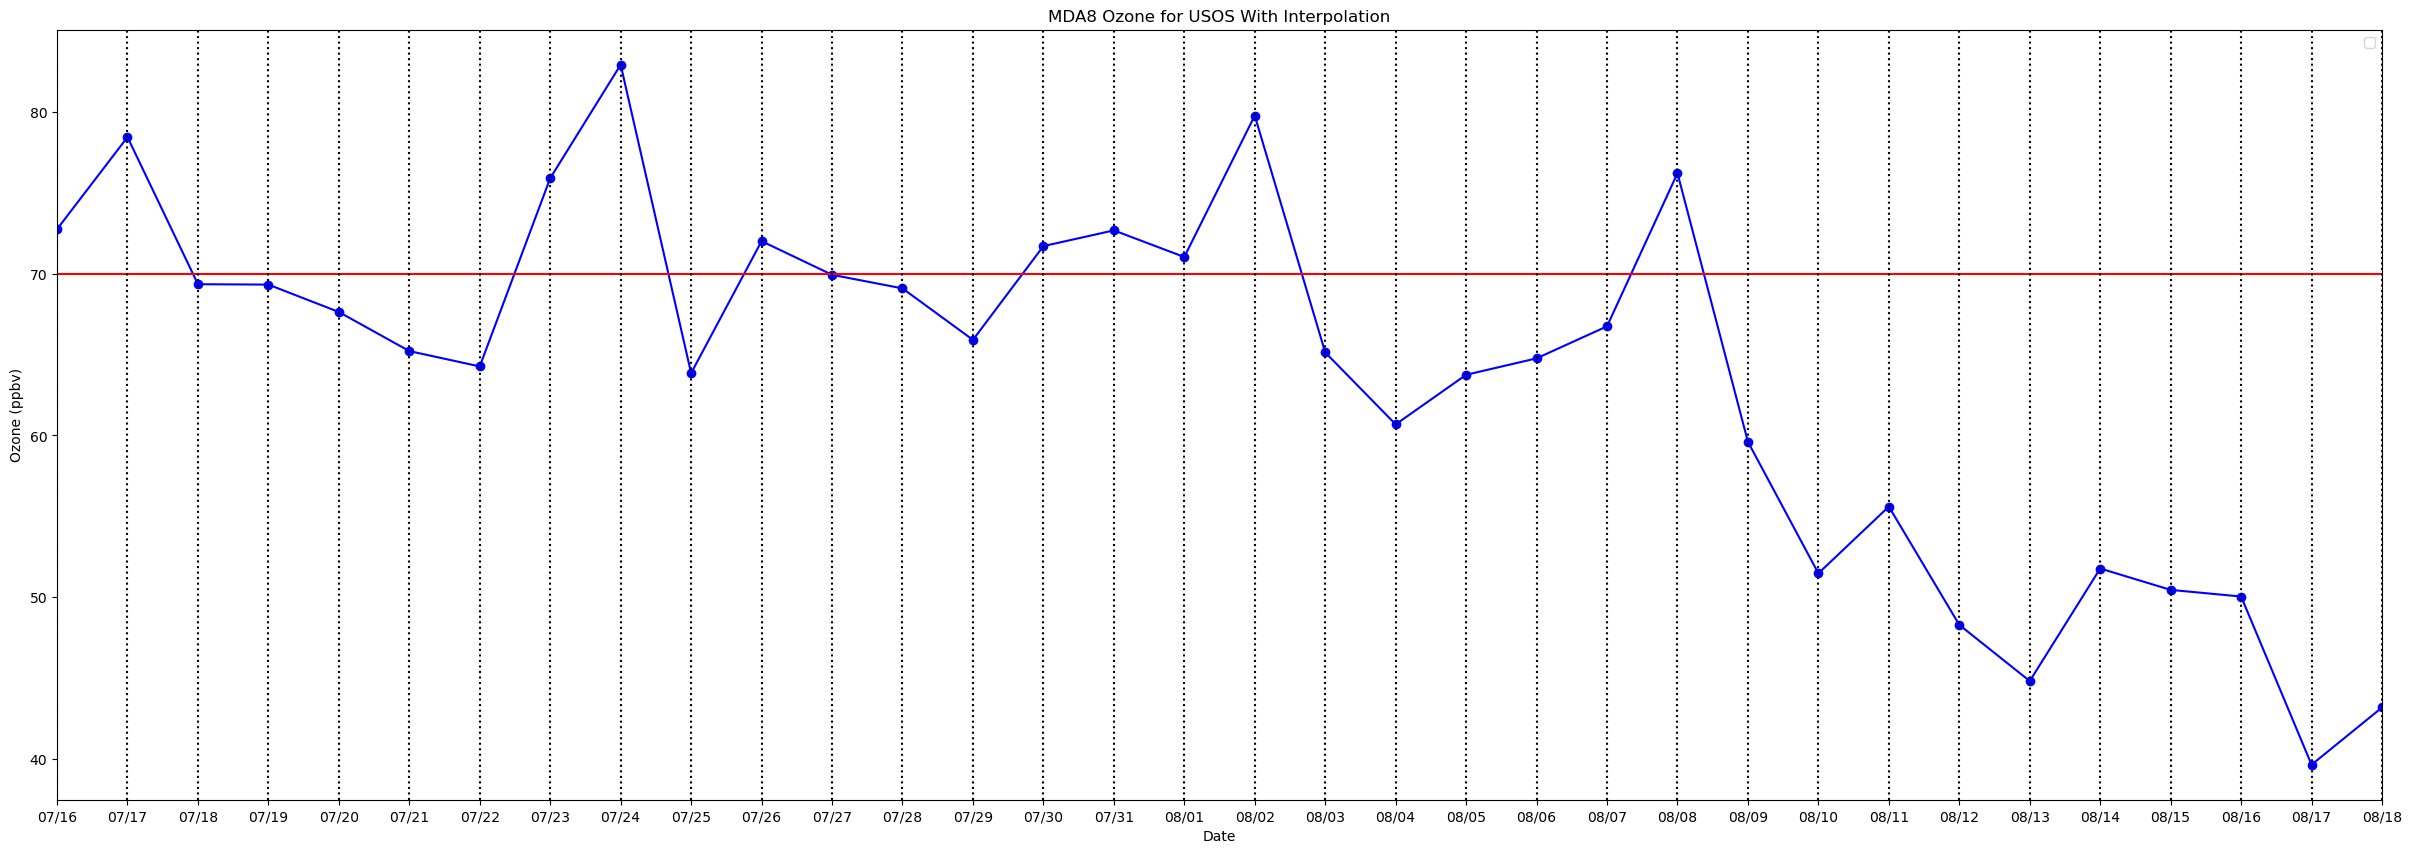

In [18]:
fig, ax1 = plt.subplots(figsize = (30,10))

ax1.margins(x=0)

ax1.plot(adjuststart_daily_max_8hr_avg_ozone.index, adjuststart_daily_max_8hr_avg_ozone, color='b',marker='o')

ax1.set_ylabel('Ozone (ppbv)')
ax1.set_xlabel('Date')

ax1.hlines(y=70, xmin = adjuststart_daily_max_8hr_avg_ozone.index[0], xmax = adjuststart_daily_max_8hr_avg_ozone.index[len(adjuststart_daily_max_8hr_avg_ozone)-1], color = 'r')

ax1.set_xticks(adjuststart_daily_max_8hr_avg_ozone.index)
ax1.set_xticklabels(adjuststart_daily_max_8hr_avg_ozone.index.strftime('%m/%d'))

# midnight_vals_30min = []
# for midnight_idx_30min in range(16,len(df_adjuststart_30min_ozone.index),48):
#     midnight_vals_30min.append(df_adjuststart_30min_ozone.index[midnight_idx_30min])
for day_pos_30min in adjuststart_daily_max_8hr_avg_ozone.index:
    ax1.axvline(day_pos_30min, color = 'black', linestyle = 'dotted')

lines, labels = ax1.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines, labels, loc=0)
plt.title('MDA8 Ozone for USOS With Interpolation')

With interpolation, we have that the days that are passing the MDA8 ozone of 70 ppbv are:
* 7/16, 7/17
 <br/> 

* 7/23, 7/24
 <br/> 

* 7/26
 <br/> 

* 7/30, 7/31, 8/01, 8/02
 <br/> 

* 8/08

Text(0.5, 1.0, 'With Interpolation')

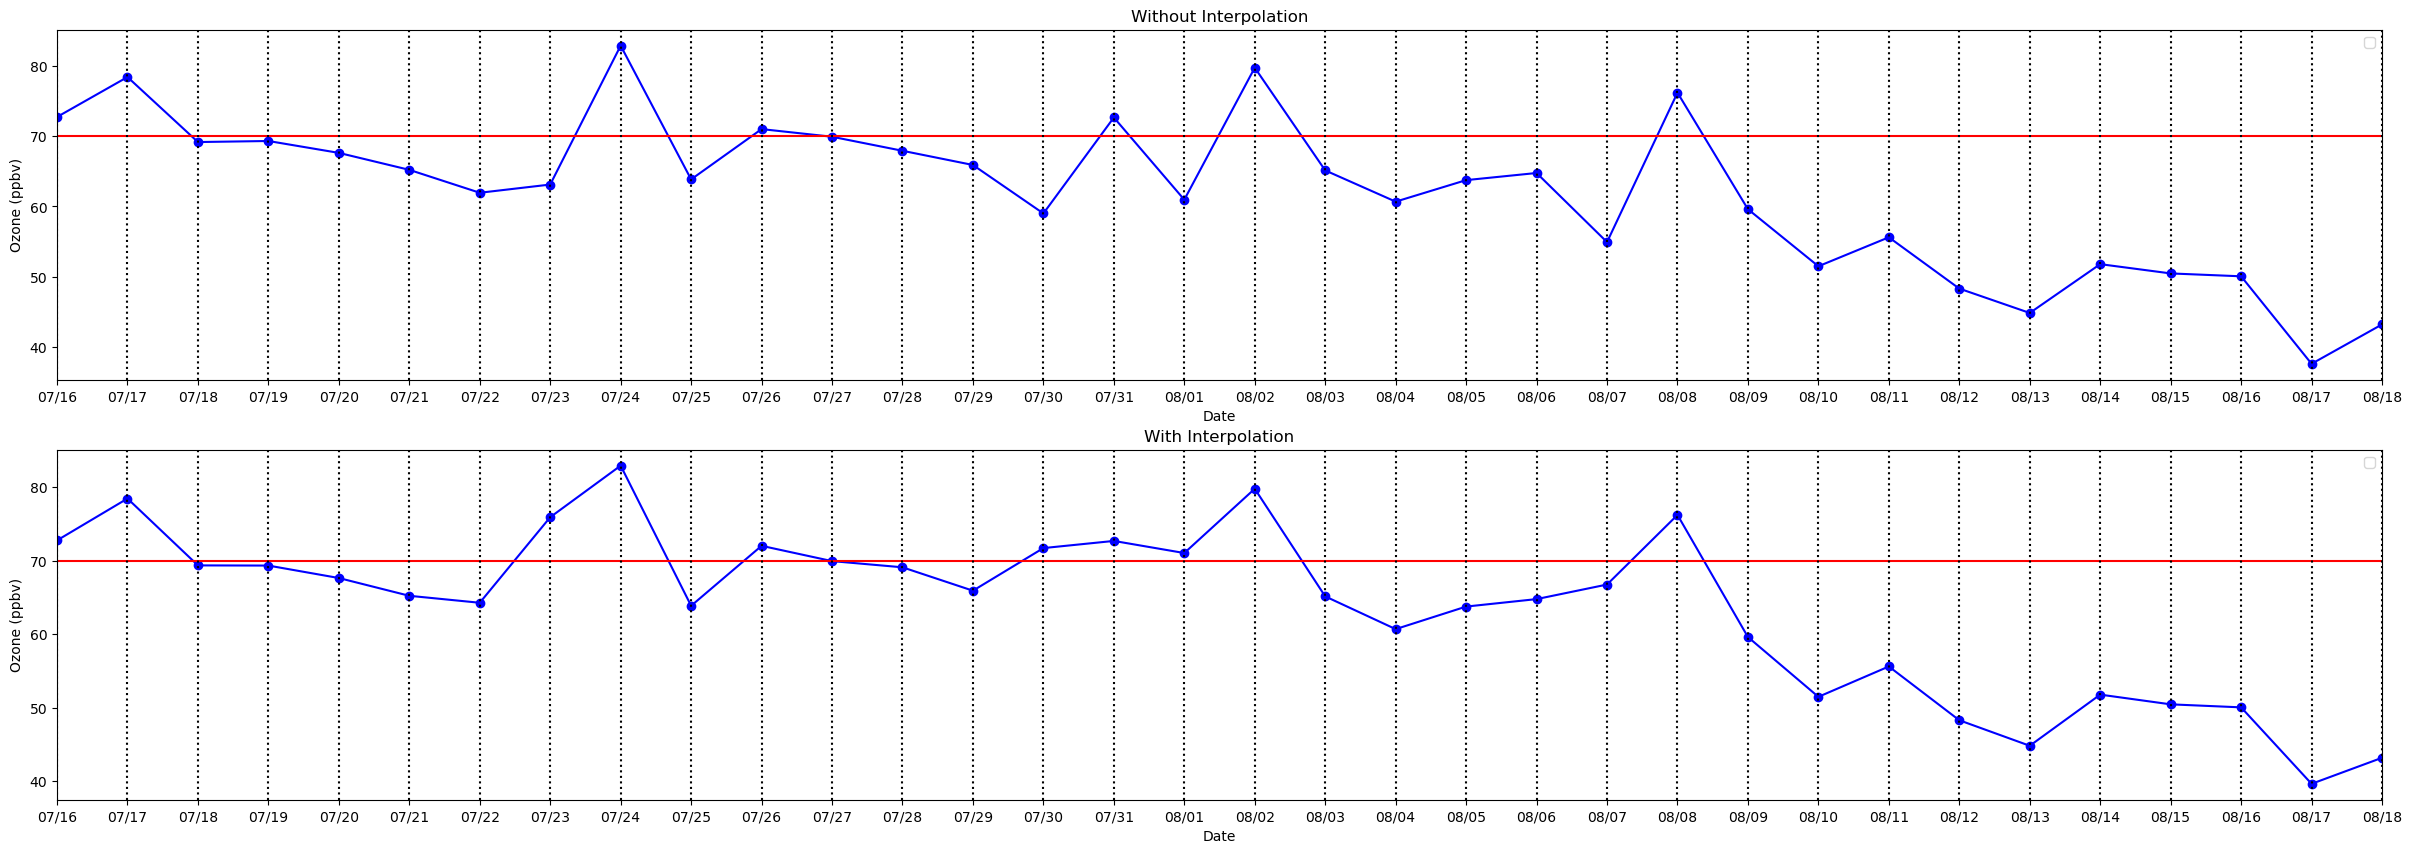

In [27]:
fig, ax = plt.subplots(2,1, figsize = (30,10))

ax[0].margins(x=0)
ax[0].plot(daily_max_8hr_avg_ozone.index, daily_max_8hr_avg_ozone, color='b',marker='o')

ax[0].set_ylabel('Ozone (ppbv)')
ax[0].set_xlabel('Date')

ax[0].hlines(y=70, xmin = daily_max_8hr_avg_ozone.index[0], xmax = daily_max_8hr_avg_ozone.index[len(daily_max_8hr_avg_ozone)-1], color = 'r')

ax[0].set_xticks(daily_max_8hr_avg_ozone.index)
ax[0].set_xticklabels(daily_max_8hr_avg_ozone.index.strftime('%m/%d'))

# midnight_vals_30min = []
# for midnight_idx_30min in range(16,len(df_adjuststart_30min_ozone.index),48):
#     midnight_vals_30min.append(df_adjuststart_30min_ozone.index[midnight_idx_30min])
for day_pos_30min in daily_max_8hr_avg_ozone.index:
    ax[0].axvline(day_pos_30min, color = 'black', linestyle = 'dotted')


lines, labels = ax[0].get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax[0].legend(lines, labels, loc=0)
ax[0].set_title('Without Interpolation')


ax[1].margins(x=0)

ax[1].plot(adjuststart_daily_max_8hr_avg_ozone.index, adjuststart_daily_max_8hr_avg_ozone, color='b',marker='o')

ax[1].set_ylabel('Ozone (ppbv)')
ax[1].set_xlabel('Date')

ax[1].hlines(y=70, xmin = adjuststart_daily_max_8hr_avg_ozone.index[0], xmax = adjuststart_daily_max_8hr_avg_ozone.index[len(adjuststart_daily_max_8hr_avg_ozone)-1], color = 'r')

ax[1].set_xticks(adjuststart_daily_max_8hr_avg_ozone.index)
ax[1].set_xticklabels(adjuststart_daily_max_8hr_avg_ozone.index.strftime('%m/%d'))

# midnight_vals_30min = []
# for midnight_idx_30min in range(16,len(df_adjuststart_30min_ozone.index),48):
#     midnight_vals_30min.append(df_adjuststart_30min_ozone.index[midnight_idx_30min])
for day_pos_30min in adjuststart_daily_max_8hr_avg_ozone.index:
    ax[1].axvline(day_pos_30min, color = 'black', linestyle = 'dotted')

lines, labels = ax[1].get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax[1].legend(lines, labels, loc=0)
ax[1].set_title('With Interpolation')